# NB2 Journal Data Frame Cleaning

**Purpose**: Here, we start with a collection of data frames for publications pulled from [Scimago Journal & Country Rank](https://www.scimagojr.com/journalrank.php) including metrics about publications divided into different subject areas. Given the scope of researchers who have published work in perovskites, we have pulled publications from the following subject areas:
- Materials Science
- Environmental Science
- Engineering
- Energy
- Chemistry
- Physics and Astronomy
- Chemical Engineering
- Multidisciplinary (contains journals of interest such as Nature and Science)

The goal of this notebook is to concatenate the individual data frames into a single data frame called `jour_df` and clean that data frame such that we can *join* the titles of the publications onto the publication titles in the `papers_df` so that `papers_df` will contain metric information about the source that will influence the entry's rank.

## Step 1: Concatenate data frames.

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

To ensure the successful conversion of the original data from the CSV file into a Pandas data frame, we must first perform preliminary text format editing. We accomplish this by iterating through the lines in the CSV file and using the `.replace()` method to modify any strings that require reformatting. We then append each line, whether edited or not, to a `txt` file that will be utilized in generating the Pandas data frame. Our specific modification involves replacing instances of `&amp;` with `&amp;`, as the delimiter is `;` and we want to avoid the columns splitting the string after `&amp;`.

*Note*: Attempts were made to edit the CSV files directly, but this ended up being the most effective method.

In [2]:
folder_path = r'G:\My Drive\BrainStation\BrainStationCapstone\Scripts and Notebooks\Raw Data\2023-03-03 Journal IF Datasets'
folder_out = r'G:\My Drive\BrainStation\BrainStationCapstone\Scripts and Notebooks\Raw Data\2023-03-03 Journal IF Datasets\output'
folder = os.listdir(folder_path)[:-1]

print('Here are the CSV Files being Edited:')
for file in folder:
    path = os.path.join(folder_path, file)
    print(file)
    out_path = os.path.join(folder_out, file).replace('.csv', '')
    with open(path, 'r') as f:
        with open(out_path + '_out.txt', 'a') as g:
            for idx, line in enumerate(f):
                    # need to replace '&amp' with &
                    new_line = line.replace('&amp;', '&')
                    g.write(new_line)

Here are the CSV Files being Edited:
scimagojr 2021  Subject Area - Materials Science.csv
scimagojr 2021  Subject Area - Environmental Science.csv
scimagojr 2021  Subject Area - Engineering.csv
scimagojr 2021  Subject Area - Energy.csv
scimagojr 2021  Subject Area - Chemistry.csv
scimagojr 2021  Subject Area - Physics and Astronomy.csv
scimagojr 2021  Subject Area - Chemical Engineering.csv
scimagojr 2021  Subject Area - Multidisciplinary.csv


Next, we will concatenate the individual data frames stored in the `txt` files into one data frame titled `jour_df`.

In [3]:
folder = os.listdir(folder_out)

jour_df = pd.DataFrame()

print('Here are the TXT Files being Edited:')
for file in folder:
    path = os.path.join(folder_out, file)
    print(file)
    temp_file = np.genfromtxt(path, delimiter=';', usecols = (2,3,5,7,15,16), dtype = '<U500')
    temp_df = pd.DataFrame(temp_file[1:], columns = temp_file[0,:])
    jour_df = pd.concat([jour_df, temp_df], axis = 0)

Here are the TXT Files being Edited:
scimagojr 2021  Subject Area - Materials Science_out.txt
scimagojr 2021  Subject Area - Environmental Science_out.txt
scimagojr 2021  Subject Area - Engineering_out.txt
scimagojr 2021  Subject Area - Energy_out.txt
scimagojr 2021  Subject Area - Chemistry_out.txt
scimagojr 2021  Subject Area - Physics and Astronomy_out.txt
scimagojr 2021  Subject Area - Chemical Engineering_out.txt
scimagojr 2021  Subject Area - Multidisciplinary_out.txt


Here is the resulting data frame `jour_df`

In [4]:
jour_df.head()

,Title,Type,SJR,H index,Country,Region
0,"""Nature Reviews Materials""",journal,"23,876",131,United Kingdom,Western Europe
1,"""Nature Energy""",journal,"16,736",160,United States,Northern America
2,"""Nature Materials""",journal,"12,229",507,United Kingdom,Western Europe
3,"""Nature Nanotechnology""",journal,"11,698",368,United Kingdom,Western Europe
4,"""Nature Photonics""",journal,"10,991",339,United Kingdom,Western Europe


In [5]:
row, col = jour_df.shape
print(f'The data frame has {row} rows and {col} columns')

The data frame has 162801 rows and 6 columns


Here are the descriptions of the columns that make up `jour_df` (pulled from https://www.scimagojr.com/journalrank.php)

- `Title`: The title of the publication 
- `Type`: The type of publication (journal article, book, etc.)
- `SJR`: "SCImago Journal Rank indicator. It is a measure of journal's impact, influence or prestige. It expresses the average number of years weighted citations received in the selected year by the documents published in the journal in the three previous years.
- `H index`: "Journal's number of citations (h) that have received at least h citations over the whole period"
- `Country`: The location of the publisher
- `Region`: The region of the publisher's country.

## Step 2: Cleaning `jour_df`

First, let's check to see if `jour_df` has any duplicate entries. We'd expect there to be duplicate publication entires if a publication is present in more than one subject area's data frame. (Example: the publication `ACS Nano` could be considered to span both the Materials Science and Chemistry subject area, so it would be added to `jour_df` from both subject area data frames).

In [6]:
num = jour_df.duplicated().sum()
print(f'There are {num} duplicated entires')

There are 156279 duplicated entires


Let's remove the duplicated entries.

In [7]:
jour_df = jour_df.drop_duplicates(ignore_index = True)

In [8]:
num = jour_df.duplicated().sum()
print(f'There are {num} duplicated entires')

There are 0 duplicated entires


In [9]:
row, col = jour_df.shape
print(f'The data frame has {row} rows and {col} columns')

The data frame has 6522 rows and 6 columns


It looks like most of the entires in `jour_df` were duplicated since the the data frame originally had over 57,000 entries and now has about 6,5000.

Let's look at some formatting changes we can make to the entires.

In [10]:
jour_df.head(5)

,Title,Type,SJR,H index,Country,Region
0,"""Nature Reviews Materials""",journal,"23,876",131,United Kingdom,Western Europe
1,"""Nature Energy""",journal,"16,736",160,United States,Northern America
2,"""Nature Materials""",journal,"12,229",507,United Kingdom,Western Europe
3,"""Nature Nanotechnology""",journal,"11,698",368,United Kingdom,Western Europe
4,"""Nature Photonics""",journal,"10,991",339,United Kingdom,Western Europe


In [11]:
jour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6522 entries, 0 to 6521
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Title    6522 non-null   object
 1   Type     6522 non-null   object
 2   SJR      6522 non-null   object
 3   H index  6522 non-null   object
 4   Country  6522 non-null   object
 5   Region   6522 non-null   object
dtypes: object(6)
memory usage: 305.8+ KB


`Title`, `Type` `Country` and `Region` appear to be assigned the appropriate data type (object) while `SJR` and `H index` should be changed to a numeric data type. First, let's  replace `,` with `.` in `SJR` so it can be interpreted as a `float` and then convert `SJR` and `H index` into numeric data types.

In [12]:
jour_df = jour_df.assign(SJR = jour_df.apply(lambda x: x['SJR'].replace(',', '.'), axis = 1))

In [13]:
for idx in jour_df['H index'].index:
    try: 
        # try to convert str to integer
        jour_df.loc[idx, 'H index'] = int(jour_df.loc[idx, 'H index'])
    except:
        # set value to null if the changing the data type doesn't work
        jour_df.loc[idx, 'H index'] = np.nan 
    
# Convert to float data type (using float insted of int because I can't conver NAN to int)
jour_df['H index'] = jour_df['H index'].astype('float16')

for idx in jour_df['SJR'].index:
    try: 
        # try to convert string to float
        jour_df.loc[idx, 'SJR'] = float(jour_df.loc[idx, 'SJR'])
    except:
        # set value to null if the changing the data type doesn't work
        jour_df.loc[idx, 'SJR'] = np.nan

# Convert to float data type
jour_df['SJR'] = jour_df['SJR'].astype('float64')

In [14]:
jour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6522 entries, 0 to 6521
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Title    6522 non-null   object 
 1   Type     6522 non-null   object 
 2   SJR      6433 non-null   float64
 3   H index  6520 non-null   float16
 4   Country  6522 non-null   object 
 5   Region   6522 non-null   object 
dtypes: float16(1), float64(1), object(4)
memory usage: 267.6+ KB


In [15]:
jour_df.head(5)

,Title,Type,SJR,H index,Country,Region
0,"""Nature Reviews Materials""",journal,23.876,131.0,United Kingdom,Western Europe
1,"""Nature Energy""",journal,16.736,160.0,United States,Northern America
2,"""Nature Materials""",journal,12.229,507.0,United Kingdom,Western Europe
3,"""Nature Nanotechnology""",journal,11.698,368.0,United Kingdom,Western Europe
4,"""Nature Photonics""",journal,10.991,339.0,United Kingdom,Western Europe


It looks like the data type of `SJR` and `H index` successfully changed into numeric data types! Now let's continue editing the format of the `Title` column .Let's start with remove `""` from the values in `Title`.

In [16]:
jour_df["Title"] = jour_df["Title"].str.replace('"', '')

In [17]:
jour_df.head(5)

,Title,Type,SJR,H index,Country,Region
0,Nature Reviews Materials,journal,23.876,131.0,United Kingdom,Western Europe
1,Nature Energy,journal,16.736,160.0,United States,Northern America
2,Nature Materials,journal,12.229,507.0,United Kingdom,Western Europe
3,Nature Nanotechnology,journal,11.698,368.0,United Kingdom,Western Europe
4,Nature Photonics,journal,10.991,339.0,United Kingdom,Western Europe


Let's also strip an white space from the remaining object columns for good measure.

In [18]:
for col in jour_df.select_dtypes('object').columns:
    jour_df[col] = jour_df[col].str.strip()

In [19]:
jour_df.head(5)

,Title,Type,SJR,H index,Country,Region
0,Nature Reviews Materials,journal,23.876,131.0,United Kingdom,Western Europe
1,Nature Energy,journal,16.736,160.0,United States,Northern America
2,Nature Materials,journal,12.229,507.0,United Kingdom,Western Europe
3,Nature Nanotechnology,journal,11.698,368.0,United Kingdom,Western Europe
4,Nature Photonics,journal,10.991,339.0,United Kingdom,Western Europe


Next, let's assess the null values in the data frame.

In [20]:
jour_df.isna().sum()

Title       0
Type        0
SJR        89
H index     2
Country     0
Region      0
dtype: int64

It looks like `SJR` and `H index` have the most null values. Let's investigate the null values in the `SJR` column.

In [21]:
jour_df[jour_df['SJR'].isna()].head(5)

,Title,Type,SJR,H index,Country,Region
1356,Earozoru Kenkyu,journal,NaN,1.0,Japan,Asiatic Region
1357,Functional Differential Equations,journal,NaN,1.0,Israel,Middle East
1358,"Himia, Fizika ta Tehnologia Poverhni",journal,NaN,1.0,Ukraine,Eastern Europe
1359,Informacion Tecnologica (discontinued),journal,NaN,15.0,Chile,Latin America
1360,Makara Journal of Science,journal,NaN,1.0,Indonesia,Asiatic Region


From investigating the entires on the [website](https://www.scimagojr.com/), it appears that the null entries are due to the website having no data on to generate a `SJR` value for the journal. For now, let's leave those columns as null values and decide to keep them once we combined the entires in `jour_df` with `papers_df`.

Let's investigate the entires with null values for `H index`

In [22]:
jour_df[jour_df['H index'].isna()].head(5)

,Title,Type,SJR,H index,Country,Region
1367,Title,Type,NaN,NaN,Country,Region
6037,Numerical Heat Transfer,"Part A: Applications""",NaN,NaN,"33,56",United Kingdom


It looks like the first row (index = 1367) is just the heading, so that row can be deleted.

In [23]:
jour_df = jour_df.drop(1367)

The second row (index = 6037) appears to be an entry that needs to be manually reformatted. Let's look at that row more closely.

In [24]:
jour_df.loc[6037, :]

Title      Numerical Heat Transfer
Type         Part A: Applications"
SJR                            NaN
H index                        NaN
Country                      33,56
Region              United Kingdom
Name: 6037, dtype: object

We can use the information [directly from the website](https://www.scimagojr.com/journalsearch.php?q=21578&tip=sid&clean=0) to reformat this entry.

In [25]:
jour_df.loc[6037, :] = ['Numerical Heat Transfer; Part A: Applications', 'journal', 0.684 ,75, 'United Kingdom', 'Western Europe']

Now let's look at the null values.

In [26]:
jour_df.isna().sum()

Title       0
Type        0
SJR        87
H index     0
Country     0
Region      0
dtype: int64

It looks like all the `H index` null values were dropped and we dropped two null values in the `SJR` columns as well.

Let's investigate the values in the `Type` column.

Text(0.5, 1.0, 'Distribution of Types')

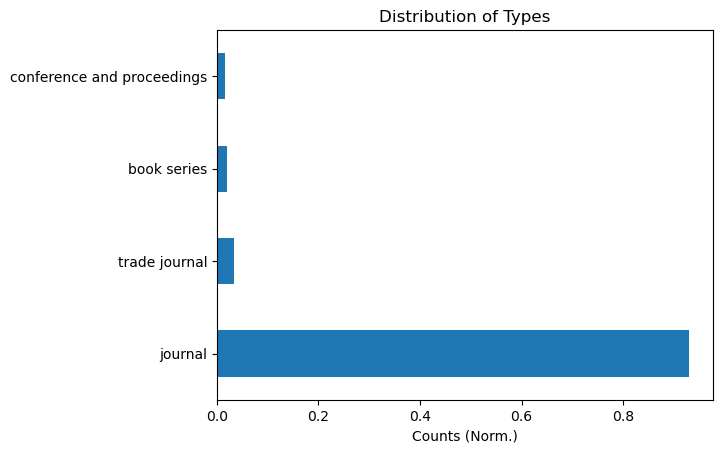

In [27]:
jour_df['Type'].value_counts(normalize = True).plot(kind = 'barh')
plt.xlabel('Counts (Norm.)')
plt.title('Distribution of Types')

It looks like the types match up similarly with the publication types chosen for the `papers_df`. However, we have an additional category, `trade journal`, but that may include some publications in the `papers_df` so we'll keep all the publications from each category.

Next, let's assess the contents in `Title`

In [28]:
jour_df['Title'].value_counts(normalize = True)

Engineering Journal                                 0.000307
Journal of Marine Science and Technology            0.000307
Journal of Engineering Research                     0.000307
Water and Energy International                      0.000307
Engineering                                         0.000307
                                                      ...   
Journal of Environmental Studies and Sciences       0.000153
ISH Journal of Hydraulic Engineering                0.000153
Human-Wildlife Interactions                         0.000153
Emu                                                 0.000153
Journal of Scientific Exploration (discontinued)    0.000153
Name: Title, Length: 6516, dtype: float64

There should be an equal number of unique `Title` values to the number of rows in the data frame, let's check if thats true.

In [29]:
jour_df['Title'].value_counts(normalize = True).count() == jour_df.shape[0]

False

It appears that there are repeated values in `Title`. Let's try to find them.

In [30]:
jour_df.groupby('Title').size()[jour_df.groupby('Title').size() > 1]

Title
Engineering                                 2
Engineering Journal                         2
Journal of Engineering Research             2
Journal of Marine Science and Technology    2
Water and Energy International              2
dtype: int64

Let's investigate the entries with repeated values from `Title`

In [31]:
jour_df[jour_df['Title'] == 'Engineering']

,Title,Type,SJR,H index,Country,Region
115,Engineering,journal,1.614,59.0,United Kingdom,Western Europe
5058,Engineering,journal,0.101,2.0,United Kingdom,Western Europe


In [32]:
jour_df[jour_df['Title'] == 'Engineering Journal']

,Title,Type,SJR,H index,Country,Region
4257,Engineering Journal,journal,0.270,22.0,Thailand,Asiatic Region
4312,Engineering Journal,trade journal,0.254,25.0,United States,Northern America


In [33]:
jour_df[jour_df['Title'] == 'Journal of Marine Science and Technology']

,Title,Type,SJR,H index,Country,Region
3420,Journal of Marine Science and Technology,journal,0.771,50.0,Japan,Asiatic Region
4335,Journal of Marine Science and Technology,journal,0.249,29.0,Taiwan,Asiatic Region


From the sample of 3 journals with repeated values for `Title`, it looks like the duplications originate from a publication with the same name having a different country of origin, or metric such as `H index`. To reduce confusion when joining the `papers_df` on the `jour_df`, let's remove duplicate entries with the lower `H index` value, since its less likely to be the publication that the citation is referring to.

In [34]:
# First sort the entires so that entires with a higher H index is sorted first, therefore the duplicated entries with the lower entries will be deleted.
jour_df = jour_df.sort_values('H index', ascending= False).drop_duplicates('Title', keep = 'first')

In [35]:
result = jour_df['Title'].value_counts(normalize = True).count() == jour_df.shape[0]
print('Is there an equal number of unique Title values to the number of rows in the data frame?', result)

Is there an equal number of unique Title values to the number of rows in the data frame? True


It looks like duplicated entires were properly addressed!

Let's look into the distribution of the values for `Country` and `Region`

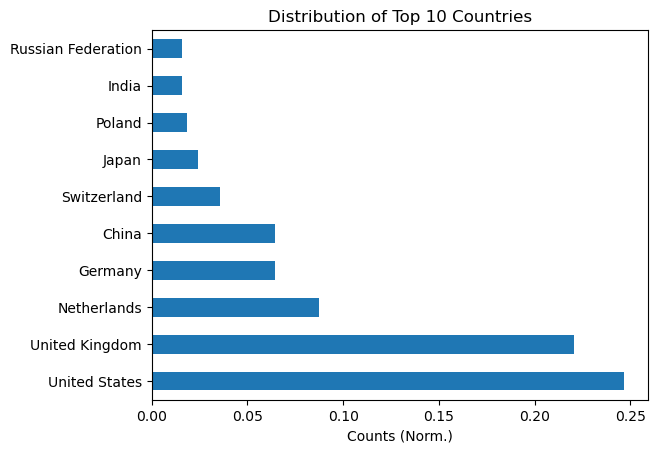

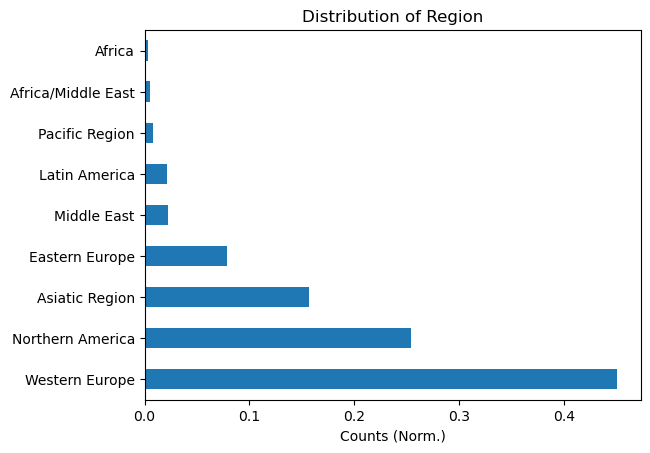

In [36]:
jour_df['Country'].value_counts(normalize = True)[:10].plot(kind = 'barh')
plt.xlabel('Counts (Norm.)')
plt.title('Distribution of Top 10 Countries')
plt.show()

jour_df['Region'].value_counts(normalize = True).plot(kind = 'barh')
plt.xlabel('Counts (Norm.)')
plt.title('Distribution of Region')
plt.show()

In [37]:
jour_df[['Country', 'Region']].describe()

,Country,Region
count,6516,6516
unique,84,9
top,United States,Western Europe
freq,1607,2935


With 84 countries and the United States, United Kingdom and Netherlands alone accounting for 50% of the counts, `Country` might not be helpful in ranking the entires but could used as an interesting metric to see the distribution of publishing locations for the entires in `papers_df`. The same can be said for the values in `Region` as well, therefore, let's keep those columns in the data frame.

## Step 3: Reformat the values in `Title` 

Our end goal is to join the values in `jour_df` onto `papers_df` using the names of the publications. For the joining to work, the names of the publications must have the same format. Therefore, we must apply a standard strip format for all the values in both the `Title` column of `jour_df` and the `Source` column of `papers_df`. The format will follow the following criteria:

1. Encode the title in ASCII
2. No leading articles (Remove The, A/An at the beginning of the Titles)
3. Replace the character `&` with `and`
4. Remove remaining special characters
5. Remove double spacing
6. Remove any qualifiers such as `(discontinued)`
7. All characters are lower case

We'll use the function `edit_title` to apply these formatting edits using regex. We'll assign the data frame with the reformatted values for `Title` under the variable `test_df`.

In [38]:
import re

def edit_title(row):
    '''
    
    This function takes publication titles and uses regex to edit the format of that value.
    
    '''
    title = row
    
    assert isinstance(title, str), 'Input parameter must be a string'
    
    # Encode the titles in ASCII 
    title = title.encode('ascii', 'ignore').decode('ascii')
    
    # Get rid of 'The'
    title = re.sub(r'^The\s', '', title)
    
    # Get rid of '(discontinued)'
    title = re.sub(r'\(discontinued\)', '', title)
    
    # Insert spaces in '&word' case
    title = re.sub(r'\&\+?', 'and ', title)
    
    # Get rid of special characters 
    title = re.sub(r'[!@#$%\^\*\(\)-:\.=,\+\_]', '', title)
    
    # Get rid of double spacing
    title = re.sub(r'  ', ' ', title)
    
    return title.strip().lower()

In [39]:
test_df = jour_df.assign(Title = jour_df['Title'].apply(edit_title))

In [40]:
test_df.head(10)

,Title,Type,SJR,H index,Country,Region
6404,nature,journal,17.897,1276.0,United Kingdom,Western Europe
6405,science,journal,14.589,1229.0,United States,Northern America
6407,proceedings of the national academy of science...,journal,4.184,805.0,United States,Northern America
5369,chemical reviews,journal,18.718,745.0,United States,Northern America
5917,physical review letters,journal,3.246,647.0,United States,Northern America
5374,journal of the american chemical society,journal,5.728,644.0,United States,Northern America
5375,angewandte chemie international edition,journal,5.126,579.0,United Kingdom,Western Europe
7,advanced materials,journal,8.663,563.0,United States,Northern America
5370,chemical society reviews,journal,14.529,552.0,United Kingdom,Western Europe
33,nano letters,journal,3.761,511.0,United States,Northern America


Let's check to make sure the number of unique values in `Title` are preserved.

In [41]:
result = test_df['Title'].value_counts().count() == jour_df['Title'].value_counts().count() 

if result == False:
    diff = np.abs(np.subtract(test_df['Title'].value_counts().count(), jour_df['Title'].value_counts().count()))
    if jour_df['Title'].value_counts().count() > test_df['Title'].value_counts().count():
        print(f'There are {diff} more unique values in jour_df than test_df')
    elif jour_df['Title'].value_counts().count() < test_df['Title'].value_counts().count():
        print(f'There are {diff} more unique values in test_df than jour_df')
else:
    print(result)

There are 2 more unique values in jour_df than test_df


Since there are more unique values in `jour_df` than `test_df`, that means there are two entires containing unique metrics for what would be considered as the same publication. This poses an issue since we are using the `Title` column as the primary key for `jour_df`. To help remove this ambiguity, let's see what the duplicated title is.

In [42]:
test_df.groupby('Title').size()[test_df.groupby('Title').size() > 1]

Title
biotech                       2
nanoscience and technology    2
dtype: int64

In [43]:
print('Before the formatting')
display(jour_df.loc[[339,1239], :])

print('After the formatting')
display(test_df[test_df['Title'] == 'nanoscience and technology'])

Before the formatting


,Title,Type,SJR,H index,Country,Region
339,Nanoscience and Technology,journal,0.734,14.0,United States,Northern America
1239,NanoScience and Technology,book series,0.115,12.0,Germany,Western Europe


After the formatting


,Title,Type,SJR,H index,Country,Region
339,nanoscience and technology,journal,0.734,14.0,United States,Northern America
1239,nanoscience and technology,book series,0.115,12.0,Germany,Western Europe


It looks like there is a book and journal article that go by the same name, `nanoscience and technology`. Let's remove the book series entry since the journal entry has a higher `H index` and because almost 80% of the entires in `papers_df` are of journal entires.

In [44]:
test_df = test_df.drop(1239)
jour_df = jour_df.drop(1239)

In [45]:
print('Before the formatting')
display(jour_df.loc[[2008,3665], :])

print('After the formatting')
display(test_df[test_df['Title'] == 'biotech'])

Before the formatting


,Title,Type,SJR,H index,Country,Region
2008,3 Biotech,journal,0.522,49.0,Switzerland,Western Europe
3665,BioTech,journal,0.530,15.0,Switzerland,Western Europe


After the formatting


,Title,Type,SJR,H index,Country,Region
2008,biotech,journal,0.522,49.0,Switzerland,Western Europe
3665,biotech,journal,0.530,15.0,Switzerland,Western Europe


It looks like there is two entries for `biotech`, one that originally was lead with a 3, and another that was not. Looking up `3 Biotech` on the [website](https://www.scimagojr.com/) didn't yield any results with that specific title, so likely an importing issue caused the format of the title to be `3 Biotech` and not `Biotech`. However, the two different values of `SJR` and `H index` suggest these entries are different publications. Despite this, we will apply our prior protocol so that entry with the larger value of `H index` will be kept since it has the highest chance of people the actual publication that would be cited.

In [46]:
test_df = test_df.drop(3665)
jour_df = jour_df.drop(3655)

Let's check again to make sure the number of unique values in `Title` are preserved.

In [47]:
result = test_df['Title'].value_counts().count() == jour_df['Title'].value_counts().count() 

if result == False:
    diff = np.abs(np.subtract(test_df['Title'].value_counts().count(), jour_df['Title'].value_counts().count()))
    if jour_df['Title'].value_counts().count() > test_df['Title'].value_counts().count():
        print(f'There are {diff} more unique values in jour_df than test_df')
    elif jour_df['Title'].value_counts().count() < test_df['Title'].value_counts().count():
        print(f'There are {diff} more unique values in test_df than jour_df')
else:
    print(result)

True


The value counts match! Next, let's check for any blank values in `Title` since encoding the values in ASCII would leave an empty string if there were no English letters, numbers or specific special characters.

In [48]:
test_df['Title'][test_df['Title'] == ''].count()

0

There are no blank values in the `Title` column. Finally, let's check the null values in `test_df`.

In [49]:
test_df.isna().sum()

Title       0
Type        0
SJR        87
H index     0
Country     0
Region      0
dtype: int64

There are no additional null values introduced. Let's replace `jour_df` with the data frame stored in `test_df` and save `test_df` as a pickle.

In [50]:
jour_df = test_df.reset_index(drop = 'True')

In [51]:
jour_df.to_pickle(r'2023-03-21_NB2_jour_df_part3.pkl')

## Step 4: Reformatting the Publication Titles in `papers_df`

First, let's reload the latest pickle for `papers_df`. In this case, its `2023-03-20_NB1_papers_df_part3.pkl`

In [52]:
papers_df = pd.read_pickle(r'2023-03-20_NB1_papers_df_part3.pkl')

In [53]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20737 entries, 0 to 20736
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           20737 non-null  int64  
 1   Authors         20737 non-null  object 
 2   Title           20737 non-null  object 
 3   Year            20737 non-null  int16  
 4   Source          20737 non-null  object 
 5   GSRank          20737 non-null  int64  
 6   Type            20737 non-null  object 
 7   ECC             20737 non-null  int64  
 8   CitesPerYear    20737 non-null  float64
 9   CitesPerAuthor  20737 non-null  int64  
 10  AuthorCount     20737 non-null  int64  
 11  query_id        20737 non-null  int16  
dtypes: float64(1), int16(2), int64(5), object(4)
memory usage: 1.7+ MB


In [54]:
papers_df.head(5)

,Cites,Authors,Title,Year,Source,GSRank,Type,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
0,4186,"D Shi, V Adinolfi, R Comin, M Yuan, E Alarousu...",Low trap-state density and long carrier diffus...,2015,Science,1,Journal article,4186,523.25,523,8,0
1,2319,"K Lin, J Xing, LN Quan, FPG de Arquer, X Gong,...",Perovskite light-emitting diodes with external...,2018,Nature,2,Journal article,2319,463.80,258,9,0
2,2163,"SA McDonald, G Konstantatos, S Zhang, PW Cyr, ...",Solution-processed PbS quantum dot infrared ph...,2005,Nature materials,3,Journal article,2163,120.17,309,7,0
3,1951,"H Tan, A Jain, O Voznyy, X Lan, FP García de A...",Efficient and stable solution-processed planar...,2017,Science,4,Journal article,1951,325.17,279,7,0
4,1897,"G Konstantatos, I Howard, A Fischer, S Hooglan...",Ultrasensitive solution-cast quantum dot photo...,2006,Nature,5,Journal article,1897,111.59,271,7,0


In `papers_df`, the name of the publication is stored in the column `Source`. Let's pass the values in `Source` into the same formatting method `edit_title` applied on the `Title` column of `jour_df`. Similarly to the process we applied in part 2, we'll assign the data frame with the reformatted values for `Source` under the variable `test_df`.

In [55]:
test_df = papers_df.assign(Source = papers_df['Source'].apply(edit_title))

In [56]:
test_df.head(5)

,Cites,Authors,Title,Year,Source,GSRank,Type,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
0,4186,"D Shi, V Adinolfi, R Comin, M Yuan, E Alarousu...",Low trap-state density and long carrier diffus...,2015,science,1,Journal article,4186,523.25,523,8,0
1,2319,"K Lin, J Xing, LN Quan, FPG de Arquer, X Gong,...",Perovskite light-emitting diodes with external...,2018,nature,2,Journal article,2319,463.80,258,9,0
2,2163,"SA McDonald, G Konstantatos, S Zhang, PW Cyr, ...",Solution-processed PbS quantum dot infrared ph...,2005,nature materials,3,Journal article,2163,120.17,309,7,0
3,1951,"H Tan, A Jain, O Voznyy, X Lan, FP García de A...",Efficient and stable solution-processed planar...,2017,science,4,Journal article,1951,325.17,279,7,0
4,1897,"G Konstantatos, I Howard, A Fischer, S Hooglan...",Ultrasensitive solution-cast quantum dot photo...,2006,nature,5,Journal article,1897,111.59,271,7,0


Let's check to make sure the number of unique values in `Source` are preserved.

In [57]:
result = test_df['Source'].value_counts().count() == papers_df['Source'].value_counts().count() 

if result == False:
    diff = np.abs(np.subtract( test_df['Source'].value_counts().count(), papers_df['Source'].value_counts().count()))
    if papers_df['Source'].value_counts().count() > test_df['Source'].value_counts().count():
        print(f'There are {diff} more unique values in papers_df than test_df')
    elif papers_df['Source'].value_counts().count() < test_df['Source'].value_counts().count():
        print(f'There are {diff} more unique values in test_df than papers_df')
else:
    print(result)

There are 953 more unique values in papers_df than test_df


We lost some unique values in `Source` between `papers_df` in `test_df`. However, unlike the `Title` column in `jour_df`, we don't need to worry about the loss of unique publication titles since `Source` won't be the primary key to join `papers_df` and `jour_df`, rather it is the foreign key for `papers_df`. If anything, the loss of 953 unique titles will hopefully ensure more entires in `papers_df` will be able to join to `jour_df` since their formatting is consistent.

Next, let's check if there are any blank values in the `Source` column of the `test_df`

In [58]:
test_df['Source'][test_df['Source'] == ''].count()

85

There are 85 entires with blank values in `papers_df`. These were expected since there were entires that used alphabets other than English, such as Russian, Mandarin, and Korean. Ideally, we could attempt to translate the names of these entries into English to see if there are matching entires in `jour_df`, but for the sake of time we will delete these entries since they only represent about 0.3% of the entires.

In [59]:
test_df = test_df.drop(test_df['Source'][test_df['Source'] == ''].index)

Let's double check to make sure all the blank entires were accounted for.

In [60]:
test_df['Source'][test_df['Source'] == ''].count()

0

All the blank entries were successfully removed. Now let's check for null values in `Source`

In [61]:
test_df['Source'].isna().sum()

0

There are no additional null values introduced. Let's replace `papers_df` with the data frame stored in `test_df` and save `papers_df` as a pickle.

In [62]:
papers_df = test_df.reset_index(drop = 'True')

In [63]:
papers_df.to_pickle(r'2023-03-21_NB2_papers_df_part4.pkl')

## Conclusion 

Here, we imported a data set of publications and their metrics as the data frame `jour_df` to be able to add additional features to `paper_df` that would describe an entry's rank. We cleaned the columns `jour_df` to ensure each column was assigned to an appropriate data type, and to ensure the formatting of the publication titles for `paper_df` and `jour_df` were consistent so that they could act as keys to join the data frames. In the next notebook, we will access the success of our method to create consistent formatting of the publication titles by attempting to join `papers_df` with `jour_df`.

---